Amide Product SMILES: COCCNC(=O)c1cn(C)c2ccccc12


[18:32:16] mapped atoms in the reactants were not mapped in the products.
  unmapped numbers are: 3 


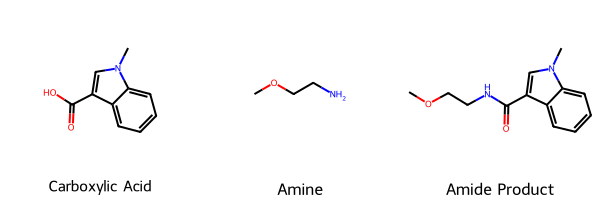

In [11]:
from rdkit import Chem
from rdkit.Chem import AllChem, Draw

# Define the reaction SMARTS for amide bond formation
# 
# Explanation of SMARTS pattern:
# - '[C:1](=[O:2])[OH:3]'  → Represents a carboxylic acid (-COOH)
#   - 'C:1' is the carbonyl carbon.
#   - 'O:2' is the carbonyl oxygen.
#   - 'OH:3' is the hydroxyl group, which will be removed during the reaction.
#
# - '[N:4]'  → Represents an amine (-NH2, -NHR, or -NR2)
#
# - The '>>' operator denotes the reaction transformation:
#   - '[C:1](=[O:2])[N:4]' → The nitrogen (N:4) is now directly bonded to the carbonyl carbon (C:1),
#     forming an **amide bond**.
#   - Water (H2O) is lost, but this is not explicitly represented in this SMARTS pattern.
reaction_smarts = '[C:1](=[O:2])[OH:3].[N:4]>>[C:1](=[O:2])[N:4]'
rxn = AllChem.ReactionFromSmarts(reaction_smarts)

# Define reactants as SMILES strings
carb_smi = 'CN1C=C(C2=CC=CC=C21)C(=O)O  '  # Decanoic acid (10-carbon saturated carboxylic acid)
am_smi = 'COCCN'  # 2-Methoxyethylamine (-NH2 group attached to an ethoxy chain)

# Convert SMILES to RDKit Mol objects
carb_mol = Chem.MolFromSmiles(carb_smi)
am_mol = Chem.MolFromSmiles(am_smi)

# Run the reaction using RDKit
product_sets = rxn.RunReactants((carb_mol, am_mol))

# Extract and sanitize products
products = []
for prod_tuple in product_sets:  # RunReactants returns tuples of possible products
    for product_mol in prod_tuple:
        Chem.SanitizeMol(product_mol)  # Ensure the molecule is chemically valid
        products.append(product_mol)  # Store the product



print("Amide Product SMILES:", Chem.MolToSmiles(products[0]))

# Visualize reactants and product side-by-side
Draw.MolsToGridImage([carb_mol, am_mol] + products, 
                           molsPerRow=3, 
                           legends=["Carboxylic Acid", "Amine", "Amide Product"])




[18:32:20] mapped atoms in the reactants were not mapped in the products.
  unmapped numbers are: 3 


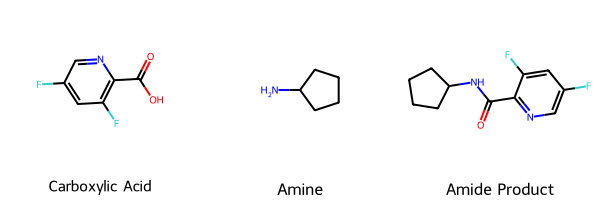

In [12]:
from rdkit import Chem
from rdkit.Chem import AllChem, Draw
import pandas as pd
from pathlib import Path

# Define the reaction SMARTS for amide bond formation
# 
# Explanation of SMARTS pattern:
# - '[C:1](=[O:2])[OH:3]'  → Represents a carboxylic acid (-COOH)
#   - 'C:1' is the carbonyl carbon.
#   - 'O:2' is the carbonyl oxygen.
#   - 'OH:3' is the hydroxyl group, which will be removed during the reaction.
#
# - '[N:4]'  → Represents an amine (-NH2, -NHR, or -NR2)
#
# - The '>>' operator denotes the reaction transformation:
#   - '[C:1](=[O:2])[N:4]' → The nitrogen (N:4) is now directly bonded to the carbonyl carbon (C:1),
#     forming an **amide bond**.
#   - Water (H2O) is lost, but this is not explicitly represented in this SMARTS pattern.
df_data = pd.read_csv('amide_lnk_data.csv')
reaction_smarts = '[C:1](=[O:2])[OH:3].[N:4]>>[C:1](=[O:2])[N:4]'
rxn = AllChem.ReactionFromSmarts(reaction_smarts)
# Define reactants as SMILES strings
carb_smi = df_data['acidSMILES']
am_smi = df_data['amineSMILES']

product_smiles_list = []



for i in range(df_data.shape[0]):
    carb_mol = Chem.MolFromSmiles(carb_smi[i])
    am_mol = Chem.MolFromSmiles(am_smi[i])
    product_sets = rxn.RunReactants((carb_mol, am_mol))
    # Extract and sanitize products
    products = []
    for prod_tuple in product_sets:  # RunReactants returns tuples of possible products
        for product_mol in prod_tuple:
            Chem.SanitizeMol(product_mol)  # Ensure the molecule is chemically valid
            products.append(product_mol)  # Store the product
    for product in products:
        productSMILES = Chem.MolToSmiles(product)
    product_smiles_list.append(productSMILES)

df_products = pd.DataFrame({'productSMILES':product_smiles_list})
df_final = pd.concat([df_data, df_products], axis=1)


# Visualize reactants and product side-by-side
Draw.MolsToGridImage([carb_mol, am_mol] + products, 
                           molsPerRow=3, 
                           legends=["Carboxylic Acid", "Amine", "Amide Product"])

In [13]:
def product_maker(df_data):
    carb_mol = Chem.MolFromSmiles(df_data['acidSMILES'])
    am_mol = Chem.MolFromSmiles(df_data['amineSMILES'])
    reaction_smarts = '[C:1](=[O:2])[OH:3].[N:4]>>[C:1](=[O:2])[N:4]'
    rxn = AllChem.ReactionFromSmarts(reaction_smarts)
    product_sets = rxn.RunReactants((carb_mol, am_mol))
    products = []
    for prod_tuple in product_sets:  # RunReactants returns tuples of possible products
        for product_mol in prod_tuple:
            Chem.SanitizeMol(product_mol)  # Ensure the molecule is chemically valid
            products.append(product_mol) 
    return Chem.MolToSmiles(product)

In [14]:
df_data['product'] = df_data.apply(product_maker)

KeyError: 'acidSMILES'

In [ ]:
df_final.to_csv('amide_lnk_data_with_products.csv', index=False)

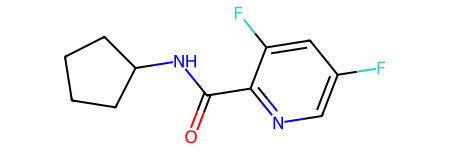

In [15]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import rdChemReactions, Draw

solvent_smarts = df_final.iloc[351, 10]

mol = Chem.MolFromSmiles(solvent_smarts)
mol


In [16]:
df = pd.read_csv('amide_lnk_data_with_products.csv')
df_prod = df['productSMILES']
df_prod[1]

'CCCCCCCCCC(=O)NCC1CCCCC1'

In [17]:
SMILES = []
for i in range(df_data.shape[0]):
    reactionSMILES = carb_smi[i].strip() +'.' + am_smi[i].strip() +'>>'+ df_prod[i].strip()
    SMILES.append(reactionSMILES)


In [18]:
rxn_SMILES = pd.DataFrame({'ReactionSMILES':SMILES})


In [ ]:
rxn_SMILES.to_csv('amide_lnk_data_reactions.csv', index=False)

In [19]:
final_SMILES = pd.concat([rxn_SMILES,df_data[['SolventSMILES', 'lnk_experiment']]], axis=1)

In [ ]:
final_SMILES.to_csv('amide_lnk_data_final.csv', index=False)

In [ ]:
final_SMILES["ΔGreac"] = final_SMILES['lnk_experiment'].apply(lambda x:x*-1*8.341*298/4184)

In [27]:
final_SMILES
final_SMILES.to_csv('amide_lnk_data_final.csv', index=False)

In [1]:
import pandas as pd
menschutkin = pd.read_csv('Solvent_List_Selection_Menschutkin_Minnesota_SMILES.csv')
menschutkin['RxnSMILES'] = menschutkin['RxnSMILES'].str.strip()
new_menschutkin = menschutkin.dropna(how= "all", axis=1)
new_menschutkin.to_csv('menshutkin_rxn_solvent_gibbs.csv', index=False)


In [ ]:
import pandas as pd
import re
chung = pd.read_csv('RxnSolvKSE_dataset_v1.1/pretraining_set/chosen_500k_data/pretraining_rxn_solvent_ddGsolv_ddHsolv_500k.csv')
chung['reactants'] = chung['rxn_smiles'].apply(lambda x:re.split(r"[>>]+",x)[0])
chung['products'] = chung['rxn_smiles'].apply(lambda x:re.split(r"[>>]+",x)[1])
chung[['reactants1', 'reactants2']] = chung['reactants'].apply(func=Smiler)
chung[['products1','products2']] = chung['products'].apply( func=Smiler)
chung

In [3]:
import numpy as np
def Smiler(smile_list):

    smiles = re.split(r"[.]+",smile_list)
    if len(smiles) == 2:
        return pd.Series(smiles)
    else:
        return pd.Series([smile_list,np.NaN])

In [40]:
reactants_df = pd.concat([chung['reactants1'], chung['reactants2']], axis=0, ignore_index = True)

df = pd.DataFrame(reactants_df)
df = df.dropna(ignore_index = True)
df = df.rename(columns={0: 'Reactants'})
df.to_csv('chung_pretraining_reactants.csv', index=False)

In [ ]:
import pandas as pd
import re
chung = pd.read_csv('../sample_scripts_for_ML_models/sample_input_file_with_data.csv')
chung['Amine'] = chung['rxn_smiles'].apply(lambda x:re.split(r"[.>>]+",x)[0])
chung.head()

,rxn_smiles,solvent_smiles,ddGsolv,ddHsolv,Amine
0,[C:1](#[C:2][C:3]([H:5])([H:6])[H:7])[H:4].[C:...,O,-0.36,1.48,[C:8]([C:9](=[C:10]([H:14])[H:15])[H:13])([H:1...
1,[C:1]([C:2]([C:3]([H:10])([H:11])[H:12])[C:4](...,OCC(C)C,3.53,8.95,[H:9][O:17][C:16]([H:18])([H:19])[H:20]
2,[C:14]([H:15])([H:16])[H:17].[C:1]([C:2]([C:3]...,O,-1.36,0.27,[C:1]([C:2]([C:3]([C:4]([H:11])([H:12])[H:13])...
3,[C:1]([O:2][C:3]=[O:4])([H:5])([H:6])[H:7].[H:...,CCOCCOCCOCC,1.97,6.33,[H:8][O:9]
4,[C:1]([O:2][C:3](=[O:4])[H:8])([H:5])([H:6])[H...,O,-3.58,-1.33,[O:9]


In [4]:
import pandas as pd

df1 = pd.read_csv('menschutkin_rxn_solvent_gibbs.csv')
df2 = pd.read_csv('Menshutkin Gibbs.csv')

men_SMILES = pd.concat([df1[['RxnSMILES','SolventSMILES']],df2['ddGsolv']], axis=1)
men_SMILES

,RxnSMILES,SolventSMILES,ddGsolv
0,C1=CC=NC=C1.C1=CC=C(C=C1)C(=O)CBr>>C1=CC=C(C=C...,CC1=CC(=NC=C1)C,-1.545953
1,C1=CC=NC=C1.C1=CC=C(C=C1)C(=O)CBr>>C1=CC=C(C=C...,C(Cl)(Cl)Cl,-1.288176
2,C1=CC=NC=C1.C1=CC=C(C=C1)C(=O)CBr>>C1=CC=C(C=C...,C1CCCC1,-0.770846
3,C1=CC=NC=C1.C1=CC=C(C=C1)C(=O)CBr>>C1=CC=C(C=C...,CCCCC=O,-1.270521
4,C1=CC=NC=C1.C1=CC=C(C=C1)C(=O)CBr>>C1=CC=C(C=C...,CCBr,-1.467659
...,...,...,...
174,C1=CC=NC=C1.C1=CC=C(C=C1)C(=O)CBr>>C1=CC=C(C=C...,C1CCOC1,-1.474406
175,C1=CC=NC=C1.C1=CC=C(C=C1)C(=O)CBr>>C1=CC=C(C=C...,CCCCC(=O)CCCC,-1.551271
176,C1=CC=NC=C1.C1=CC=C(C=C1)C(=O)CBr>>C1=CC=C(C=C...,C(=CCl)Cl,-1.501583
177,C1=CC=NC=C1.C1=CC=C(C=C1)C(=O)CBr>>C1=CC=C(C=C...,COC=O,-1.498275


In [5]:
men_SMILES.to_csv('menschutkin_final.csv', index=False)